# Validation Overview

An **evaluation-only** notebook: no new models, no re-selection, no tuning. It takes the one
configuration each approach selected in its own notebook (the lowest mean seasonal MASE over the
four validation origins) and looks at how they perform, from three angles:

1. **Overall**, per origin and on average.
2. **Before vs after the pandemic** (two origins each).
3. **Flat vs rapid-growth years**: each validation year labelled by its growth.

| Approach | Selected in | Forecast of the total |
|---|---|---|
| SARIMAX | notebook 5 | direct |
| Local ML (tuned) | notebook 7 | direct |
| Global ML | notebook 8 | bottom-up sum of the series forecasts |
| TimesFM | notebook 9 | direct (median) |
| Best ensemble (all) | notebook 10 (mean, median or inverse-MASE over all 4 models) | combination of the four above |
| Best stacking (all) | notebook 10 (Huber, linear, Ridge or Lasso over all 4 models) | combination of the four above |
| Best ensemble (best 2) | notebook 10 (mean or inverse-MASE over Local ML + SARIMAX) | combination of the best 2 models |
| Best stacking (best 2) | notebook 10 (Huber, linear, Ridge or Lasso over Local ML + SARIMAX) | combination of the best 2 models |
| Seasonal naive, naive | reference rows (grey) | same month last year / last month |

All forecasts are read from MLflow, where every notebook stored the per-origin validation
forecasts of its selected configuration. Nothing is refitted. The test set is never read.

**Leakage.** The weights of the inverse-MASE mean and the stacking regressions were learned from
validation forecasts, so notebook 10 stored their **leave-one-origin-out** forecasts: the forecast
of each origin comes from weights fitted on the other three. The mean and the median learn nothing.
No score below is therefore fitted on the months it is scored on. The **selection** of each
approach's configuration did use these four origins, so all the scores remain somewhat
optimistic; the unbiased scores come from the test year in the final notebook.


## Setup

In [92]:
import os
import tempfile
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import Markdown, display
from sklearn.metrics import r2_score

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')
LOADED_FILES = ['train.parquet', 'val.parquet']  # never test.parquet
assert 'test.parquet' not in LOADED_FILES

TARGET = 'arrival_count'
FREQ = 'ME'
SEASONAL_PERIOD = 12
COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')
MASE_EXCLUDED = (COVID_START, pd.Timestamp('2022-12-31'))  # as in notebooks 5-10

# Step 3: growth regimes (growth of the validation year over the previous year)
FLAT_GROWTH = 0.05  # |g| <= 5%: flat
RAPID_GROWTH = 0.30  # g >= 30%: rapid growth
BASE_AFFECTED = (COVID_START, pd.Timestamp('2022-06-30'))  # pandemic + recovery

APPROACH_COLORS = {
    'SARIMAX': '#1f77b4',
    'Local ML': '#ff7f0e',
    'Global ML': '#2ca02c',
    'TimesFM': '#d62728',
    'Best ensemble (all)': '#9467bd',
    'Best stacking (all)': '#8c564b',
    'Best ensemble (best 2)': '#e377c2',
    'Best stacking (best 2)': '#bcbd22',
    'Seasonal naive': '#4d4d4d',
    'Naive': '#a6a6a6',
}
BASELINES = ['Seasonal naive', 'Naive']
ORIGIN_COLORS = ['#08519c', '#6baed6', '#fd8d3c', '#a63603']

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
warnings.filterwarnings('ignore', category=FutureWarning)
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
client = mlflow.MlflowClient()


## Data Loading

1. **Actuals**: the monthly totals of `train.parquet` and `val.parquet`, only to score, to
   build the baselines and to compute the growth regimes of Step 3.
2. **Forecasts** from MLflow:
   - the four individual approaches: the latest run tagged `role = best_validation_forecasts` in each
     experiment (notebooks 5, 7, 8 and 9);
   - the best combinations from notebook 10 (tagged `role = ensemble_validation_forecasts`):
     - `Best ensemble (all)`: lowest mean seasonal MASE among all-model ensembles;
     - `Best stacking (all)`: lowest mean seasonal MASE among all-model stacking regressions;
     - `Best ensemble (best 2)`: lowest mean seasonal MASE among best-2 ensembles;
     - `Best stacking (best 2)`: lowest mean seasonal MASE among best-2 stacking regressions.
3. **Baselines**, rebuilt at every origin from the history up to it: the naive (the last month
   repeated) and the seasonal naive (the same month one year earlier).

Everything goes into one tidy table, `approach, origin, date, step, actual, forecast`, with one
row per approach, origin and forecast month (`step` = 1 … 12 months ahead).


In [93]:
def load_monthly(file_name):
    assert file_name in LOADED_FILES
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    return raw.set_index('date')[TARGET].resample(FREQ).sum()


full_series = pd.concat([load_monthly(file_name) for file_name in LOADED_FILES])
VAL_END = full_series.index[
    -1
]  # the last validation month (Aug 2025 with the current data)

MEMBER_EXPERIMENTS = {
    'SARIMAX': 'Brazil Tourism Forecasting ARIMA',
    'Local ML': 'Brazil Tourism Forecasting ML',
    'Global ML': 'Brazil Tourism Forecasting ML Global',
    'TimesFM': 'Brazil Tourism Forecasting TimesFM',
}
ENSEMBLE_EXPERIMENT = 'Brazil Tourism Forecasting Ensembles'


def experiment_id(name):
    found = mlflow.get_experiment_by_name(name)
    assert found is not None, f'experiment "{name}" not found: run its notebook first'
    return found.experiment_id


def read_forecasts(run):
    path = mlflow.artifacts.download_artifacts(
        run_id=run.info.run_id,
        artifact_path='validation_forecasts.csv',
        dst_path=tempfile.mkdtemp(),
    )
    return pd.read_csv(path, parse_dates=['date'])[
        ['origin', 'date', 'actual', 'forecast']
    ]


sources, frames = [], {}
for approach, experiment_name in MEMBER_EXPERIMENTS.items():
    runs = client.search_runs(
        [experiment_id(experiment_name)],
        filter_string="tags.role = 'best_validation_forecasts'",
        order_by=['attributes.start_time DESC'],
        max_results=1,
    )
    assert runs, f'{approach}: run the last section of its notebook first'
    frames[approach] = read_forecasts(runs[0])
    sources.append({
        'approach': approach,
        'configuration': runs[0].data.params['configuration'],
        'logged MASE_mean': runs[0].data.metrics['MASE_mean'],
        'weights': 'none (single model)',
    })

# notebook 10: the latest run of each combination, then the best of each kind and subset
ensemble_runs = client.search_runs(
    [experiment_id(ENSEMBLE_EXPERIMENT)],
    filter_string="tags.role = 'ensemble_validation_forecasts'",
    order_by=['attributes.start_time DESC'],
)
assert ensemble_runs, (
    'notebook 10: re-run it so that it stores its validation forecasts'
)
latest_per_method = {}
for run in ensemble_runs:  # newest first
    latest_per_method.setdefault(run.data.params['method'], run)

COMBINATION_TARGETS = [
    ('ensemble', 'all', 'Best ensemble (all)'),
    ('stacking', 'all', 'Best stacking (all)'),
    ('ensemble', 'best_2', 'Best ensemble (best 2)'),
    ('stacking', 'best_2', 'Best stacking (best 2)'),
]

for kind, subset, approach in COMBINATION_TARGETS:
    candidates = []
    for r in latest_per_method.values():
        r_kind = r.data.tags.get('kind')
        r_subset = r.data.tags.get('subset') or (
            'best_2' if '(best 2)' in r.data.params['method'] else 'all'
        )
        if r_kind == kind and r_subset == subset:
            candidates.append(r)
    assert candidates, f'No candidate runs found for {approach}'
    best = min(candidates, key=lambda r: r.data.metrics['MASE_mean'])
    frames[approach] = read_forecasts(best)
    method = best.data.params['method']
    sources.append({
        'approach': approach,
        'configuration': method,
        'logged MASE_mean': best.data.metrics['MASE_mean'],
        'weights': best.data.params.get('evaluation', 'none (equal or median)'),
    })

tidy = pd.concat(
    [frame.assign(approach=approach) for approach, frame in frames.items()],
    ignore_index=True,
)

# baselines, rebuilt at every origin from the history up to it
ORIGIN_LABELS = sorted(tidy['origin'].unique())
ORIGINS = {
    label: pd.Timestamp(label) + pd.offsets.MonthEnd(0) for label in ORIGIN_LABELS
}
baseline_rows = []
for label, origin in ORIGINS.items():
    history = full_series.loc[:origin]
    dates = pd.date_range(origin + pd.offsets.MonthEnd(1), periods=12, freq=FREQ)
    actual = full_series.reindex(dates).to_numpy()
    baseline_rows += [
        pd.DataFrame({
            'approach': 'Seasonal naive',
            'origin': label,
            'date': dates,
            'actual': actual,
            'forecast': history.reindex(dates - pd.offsets.MonthEnd(12)).to_numpy(),
        }),
        pd.DataFrame({
            'approach': 'Naive',
            'origin': label,
            'date': dates,
            'actual': actual,
            'forecast': history.iloc[-1],
        }),
    ]
tidy = pd.concat([tidy, *baseline_rows], ignore_index=True)
tidy['step'] = (
    (tidy['date'].dt.year - tidy['origin'].map(ORIGINS).dt.year) * 12
    + tidy['date'].dt.month
    - tidy['origin'].map(ORIGINS).dt.month
)
tidy = tidy[['approach', 'origin', 'date', 'step', 'actual', 'forecast']]

# ── checks: no date after the validation year, one consistent set of actuals ──
assert tidy['date'].max() <= VAL_END, 'a forecast month is after the validation year'
assert full_series.index.max() == VAL_END
assert tidy['step'].between(1, 12).all()
months_per_approach = tidy.groupby('approach').size()
assert (months_per_approach == 12 * len(ORIGIN_LABELS)).all(), months_per_approach
assert np.allclose(tidy['actual'], full_series.reindex(tidy['date']).to_numpy())

APPROACHES = [a for a in APPROACH_COLORS if a in set(tidy['approach'])]
print(
    f'{len(tidy)} rows: {len(APPROACHES)} approaches × {len(ORIGIN_LABELS)} origins '
    f'× 12 months | origins {ORIGIN_LABELS} | last month used: {VAL_END:%b %Y}'
)
pd.DataFrame(sources).set_index('approach')


480 rows: 10 approaches × 4 origins × 12 months | origins ['2017-08', '2018-08', '2023-08', '2024-08'] | last month used: ago 2025


,configuration,logged MASE_mean,weights
approach,,,
SARIMAX,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",0.992006,none (single model)
Local ML,XGBoost | seasonal_log_diff | last_4y | keep |...,0.982280,none (single model)
Global ML,XGBoost | seasonal_log_diff | last_6y | keep |...,1.101019,none (single model)
TimesFM,all | remove | none | calendar | symmetric,1.312290,none (single model)
Best ensemble (all),mean (all),0.948566,none (equal or median)
Best stacking (all),lasso stacking (all),1.030808,leave one origin out (penalty: nested leave on...
Best ensemble (best 2),mean (best 2),0.931758,none (equal or median)
Best stacking (best 2),huber stacking (best 2),0.946395,leave one origin out


## Scoring

One scoring function for every step, the metrics of notebooks 5 and 7:

| Metric | Definition |
|---|---|
| **Seasonal MASE** | `|y − ŷ|` divided by the in-sample MAE of the seasonal naive on the history up to the origin (pandemic pairs, April 2020 – December 2022, left out); averaged over the months |
| **RelMAE** | MAE of the approach / MAE of the seasonal naive **on the same months**. It equalizes the difficulty of the windows: the 2024-08 window (+40% shock) is hard for every approach |
| RMSE, MAE, MAPE | on arrivals |
| R² | per origin (a 12-month window) |
| Forecast Bias | `(Σy − Σŷ) / Σy × 100`, positive = under-forecast |

Within one origin the MASE scale is constant, so the MASE of a window is its MAE divided by the
origin's scale, exactly as in notebooks 5–10.

**Sanity check.** The mean MASE of SARIMAX and of the local ML model recomputed here must match the
best runs logged by notebooks 5 and 7; the notebook stops if they do not.

In [94]:
def seasonal_mase_scale(history):
    """In-sample MAE of the seasonal naive (y_t - y_{t-12}), pandemic pairs excluded."""
    diffs = (history - history.shift(SEASONAL_PERIOD)).abs()
    in_pandemic = history.index.to_series().between(*MASE_EXCLUDED)
    touches = in_pandemic | in_pandemic.shift(SEASONAL_PERIOD, fill_value=False)
    return float(diffs[~touches.to_numpy()].mean())


MASE_SCALES = {
    label: seasonal_mase_scale(full_series.loc[:origin])
    for label, origin in ORIGINS.items()
}
tidy['scale'] = tidy['origin'].map(MASE_SCALES)
seasonal_naive = tidy[tidy['approach'] == 'Seasonal naive'].set_index([
    'origin',
    'date',
])
tidy['snaive'] = (
    seasonal_naive['forecast']
    .reindex(pd.MultiIndex.from_frame(tidy[['origin', 'date']]))
    .to_numpy()
)


def score(rows, with_r2=True):
    """All metrics of a set of forecast rows (one validation window)."""
    actual, forecast = rows['actual'], rows['forecast']
    errors = actual - forecast
    metrics = {
        'MASE': float((errors.abs() / rows['scale']).mean()),
        'RelMAE': float(errors.abs().mean() / (actual - rows['snaive']).abs().mean()),
        'RMSE': float(np.sqrt((errors**2).mean())),
        'MAE': float(errors.abs().mean()),
        'MAPE': float((errors.abs() / actual).mean() * 100),
        'Forecast Bias': float((actual.sum() - forecast.sum()) / actual.sum() * 100),
    }
    if with_r2:
        metrics['R2'] = float(r2_score(actual, forecast))
    return pd.Series(metrics)


per_origin = (
    tidy
    .groupby(['approach', 'origin'])
    .apply(score, include_groups=False)
    .reset_index()
)
per_origin['period'] = np.where(
    per_origin['origin'].map(ORIGINS) < COVID_START, 'pre-pandemic', 'post-pandemic'
)
METRICS = ['MASE', 'RelMAE', 'RMSE', 'MAE', 'MAPE', 'R2', 'Forecast Bias']

# sanity check against the runs logged by notebooks 5 and 7
for approach, experiment_name, metric in [
    ('SARIMAX', MEMBER_EXPERIMENTS['SARIMAX'], 'mase_mean'),
    ('Local ML', MEMBER_EXPERIMENTS['Local ML'], 'MASE_mean'),
]:
    best_logged = client.search_runs(
        [experiment_id(experiment_name)],
        filter_string=(
            "attributes.status = 'FINISHED' and params.eval_split = 'validation'"
        ),
        order_by=[f'metrics.{metric} ASC'],
        max_results=1,
    )[0].data.metrics[metric]
    recomputed = per_origin.loc[per_origin['approach'] == approach, 'MASE'].mean()
    assert np.isclose(recomputed, best_logged, rtol=1e-6), (
        f'{approach}: recomputed mean MASE {recomputed:.6f} does not match the logged '
        f'{best_logged:.6f} — stop and check the stored forecasts'
    )
    print(
        f'{approach}: recomputed mean MASE {recomputed:.4f} = logged {best_logged:.4f}'
    )

SARIMAX: recomputed mean MASE 0.9920 = logged 0.9920
Local ML: recomputed mean MASE 0.9823 = logged 0.9823


## Step 1 — Overall Performance

The metrics of each approach at each origin, and their mean over the four origins (the ranking
of notebooks 5–10).

- **Chart A**: mean seasonal MASE by approach, sorted; the dashed line is the seasonal naive.
- **Chart B**: the MASE of each origin (one dot per origin), to show how much an approach's
  score depends on the window.
- **Chart C**: the actual values and every forecast, one panel per origin.

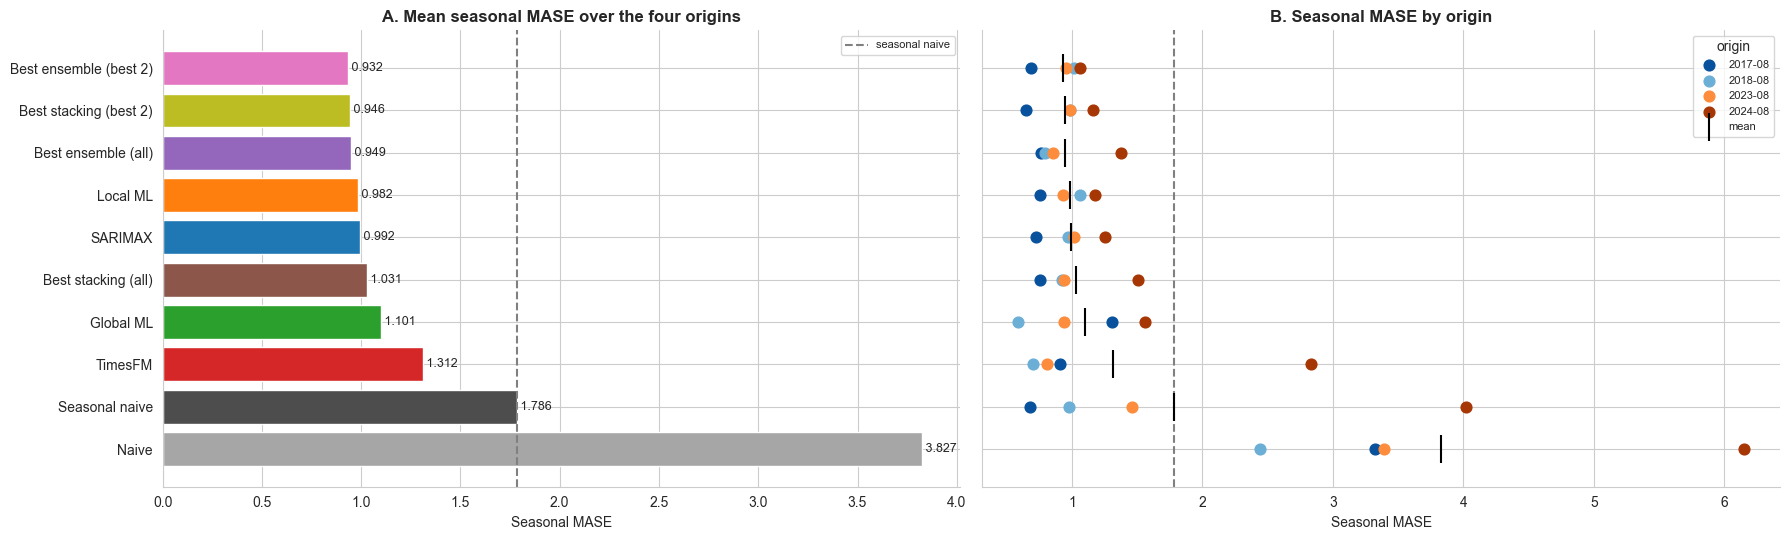

In [95]:
overall = per_origin.groupby('approach')[METRICS].mean()
ORDER = overall['MASE'].sort_values().index.tolist()
SNAIVE_MASE = overall.loc['Seasonal naive', 'MASE']

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), sharey=True)
axes[0].barh(
    ORDER[::-1],
    overall.loc[ORDER[::-1], 'MASE'],
    color=[APPROACH_COLORS[a] for a in ORDER[::-1]],
)
for i, approach in enumerate(ORDER[::-1]):
    axes[0].text(
        overall.loc[approach, 'MASE'],
        i,
        f' {overall.loc[approach, "MASE"]:.3f}',
        va='center',
        fontsize=9,
    )
axes[0].axvline(SNAIVE_MASE, color='grey', linestyle='--', label='seasonal naive')
axes[0].set_title('A. Mean seasonal MASE over the four origins', fontweight='bold')
axes[0].legend(fontsize=8)

for color, label in zip(ORIGIN_COLORS, ORIGIN_LABELS):
    rows = (
        per_origin[per_origin['origin'] == label].set_index('approach').loc[ORDER[::-1]]
    )
    axes[1].scatter(
        rows['MASE'], range(len(ORDER)), color=color, s=60, label=label, zorder=3
    )
axes[1].scatter(
    overall.loc[ORDER[::-1], 'MASE'],
    range(len(ORDER)),
    marker='|',
    s=400,
    color='black',
    label='mean',
    zorder=4,
)
axes[1].axvline(SNAIVE_MASE, color='grey', linestyle='--')
axes[1].set_title('B. Seasonal MASE by origin', fontweight='bold')
axes[1].legend(title='origin', fontsize=8)
for ax in axes:
    ax.set_xlabel('Seasonal MASE')
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

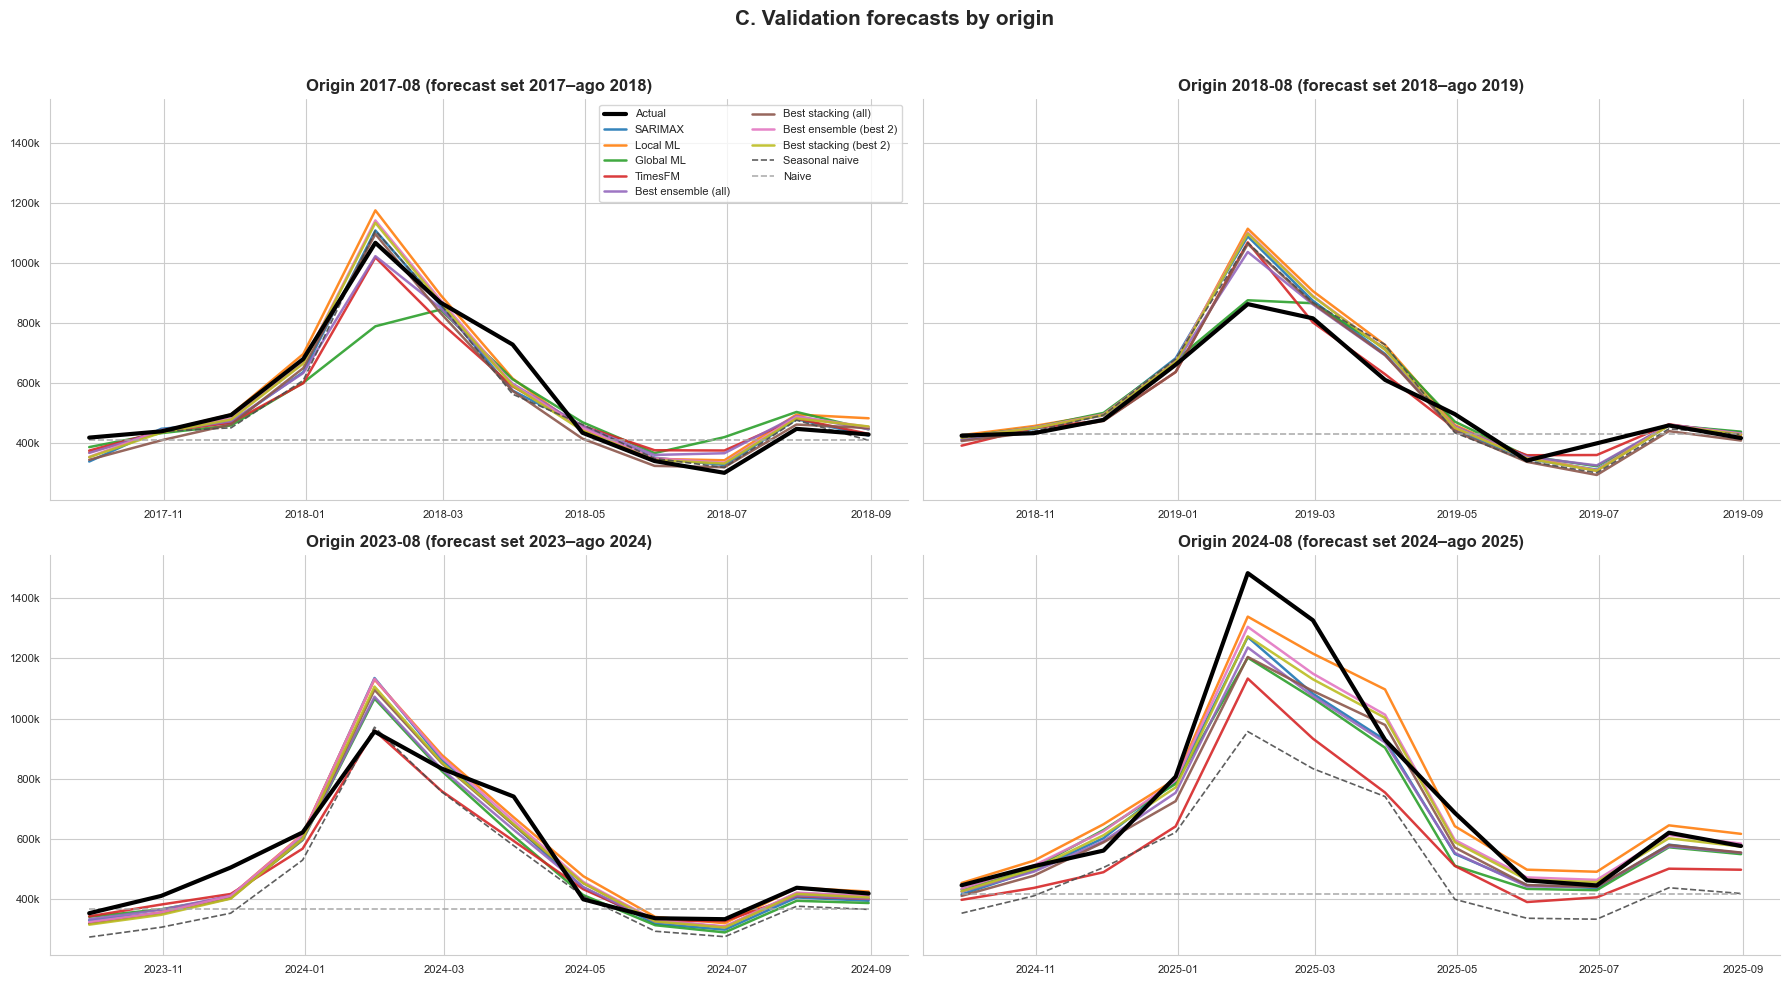

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
fig.suptitle('C. Validation forecasts by origin', fontsize=15, fontweight='bold')
for ax, label in zip(axes.flat, ORIGIN_LABELS):
    window = tidy[tidy['origin'] == label]
    actual = window.drop_duplicates('date').set_index('date')['actual']
    ax.plot(actual.index, actual, color='black', linewidth=3, label='Actual', zorder=5)
    for approach in APPROACHES:
        rows = window[window['approach'] == approach]
        is_baseline = approach in BASELINES
        ax.plot(
            rows['date'],
            rows['forecast'],
            color=APPROACH_COLORS[approach],
            linestyle='--' if is_baseline else '-',
            linewidth=1.2 if is_baseline else 1.8,
            alpha=0.9,
            label=approach,
        )
    ax.set_title(
        f'Origin {label} (forecast {actual.index[0]:%b %Y}–{actual.index[-1]:%b %Y})',
        fontweight='bold',
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)
axes.flat[0].legend(fontsize=8, ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [97]:
table = pd.concat([
    per_origin.set_index(['approach', 'origin'])[METRICS],
    overall.assign(origin='mean').set_index('origin', append=True)[METRICS],
]).reindex(pd.MultiIndex.from_product([ORDER, [*ORIGIN_LABELS, 'mean']]))
table.index.names = ['approach', 'origin']
table.round(3)

MASE  RelMAE        RMSE         MAE    MAPE     R2  Forecast Bias
approach               origin                                                                      
Best ensemble (best 2) 2017-08  0.691   1.015   51233.373   36144.844   6.599  0.947          0.165
                       2018-08  1.014   1.038   83463.927   52477.853   8.553  0.730         -5.443
                       2023-08  0.957   0.654   68310.076   49538.705   8.762  0.885          0.844
                       2024-08  1.066   0.265   83465.433   55389.785   6.045  0.937          3.291
                       mean     0.932   0.743   71618.202   48387.797   7.490  0.875         -0.286
Best stacking (best 2) 2017-08  0.646   0.949   50569.006   33785.994   6.127  0.948          1.013
                       2018-08  0.988   1.011   82438.051   51122.898   8.325  0.737         -5.062
                       2023-08  0.987   0.675   65959.770   51107.616   9.448  0.893          2.618
                       2024-08  1.165   0.290   92382.527   60561.217   6.428  0.922          5.113
                       mean     0.946   0.731   72837.339   49144.431   7.582  0.875          0.921
Best ensemble (all)    2017-08  0.764   1.123   51411.812   39960.473   7.804  0.947          2.145
                       2018-08  0.797   0.816   62645.381   41269.992   7.021  0.848         -3.780
                       2023-08  0.856   0.585   58392.774   44337.916   8.142  0.916          3.448
                       2024-08  1.377   0.342  111889.892   71568.901   7.778  0.886          8.995
                       mean     0.949   0.717   71084.965   49284.321   7.686  0.899          2.702
Local ML               2017-08  0.756   1.111   53830.212   39562.794   7.048  0.941         -2.262
                       2018-08  1.063   1.088   89177.779   54999.555   8.868  0.692         -6.317
                       2023-08  0.932   0.637   68355.526   48249.564   8.501  0.885         -0.541
                       2024-08  1.179   0.293   80115.966   61259.475   7.788  0.942         -1.349
                       mean     0.982   0.782   72869.871   51017.847   8.051  0.865         -2.617
SARIMAX                2017-08  0.723   1.063   55135.419   37853.244   6.927  0.938          2.592
                       2018-08  0.970   0.993   78273.228   50207.594   8.297  0.763         -4.570
                       2023-08  1.017   0.695   69905.692   52666.774   9.505  0.880          2.228
                       2024-08  1.258   0.313  103693.084   65358.584   7.302  0.902          7.931
                       mean     0.992   0.766   76751.856   51521.549   8.008  0.871          2.045
Best stacking (all)    2017-08  0.753   1.108   54552.266   39430.842   7.218  0.940          4.600
                       2018-08  0.927   0.949   73664.831   47975.247   8.116  0.790         -1.481
                       2023-08  0.939   0.642   63411.371   48648.219   8.947  0.901          2.553
                       2024-08  1.503   0.374  115772.913   78132.373   8.549  0.878          8.854
                       mean     1.031   0.768   76850.345   53546.670   8.207  0.877          3.632
Global ML              2017-08  1.308   1.923   99572.937   68440.298  11.973  0.799          4.719
                       2018-08  0.591   0.604   42781.988   30563.415   5.895  0.929         -2.447
                       2023-08  0.943   0.645   62898.479   48839.716   9.104  0.903          5.345
                       2024-08  1.563   0.388  125101.593   81214.072   9.051  0.858          9.463
                       mean     1.101   0.890   82588.749   57264.375   9.006  0.872          4.270
TimesFM                2017-08  0.912   1.341   60294.248   47732.630   8.922  0.926          3.530
                       2018-08  0.701   0.717   63934.322   36257.117   6.051  0.842         -1.788
                       2023-08  0.808   0.552   58742.202   41826.854   7.426  0.915          6.758
                       2024-08  2

In [98]:
best = ORDER[0]
models = [a for a in ORDER if a not in BASELINES]
beat_snaive = [a for a in models if overall.loc[a, 'MASE'] < SNAIVE_MASE]
spread = per_origin.groupby('approach')['MASE'].agg(lambda s: s.max() - s.min())
hardest = (
    per_origin[per_origin['approach'].isin(models)].groupby('origin')['MASE'].mean()
)
display(
    Markdown(f"""
**Reading — Step 1.** The best mean seasonal MASE is **{best}**
({overall.loc[best, 'MASE']:.3f}), against {SNAIVE_MASE:.3f} for the seasonal
naive; {len(beat_snaive)} of the {len(models)} approaches beat the seasonal naive
on average. The scores move a lot from one window to another: the spread between
an approach's best and worst origin goes from {spread[models].min():.2f}
({spread[models].idxmin()}) to {spread[models].max():.2f}
({spread[models].idxmax()}). The hardest window for the models is
**{hardest.idxmax()}** (mean MASE {hardest.max():.2f}) and the easiest
**{hardest.idxmin()}** ({hardest.min():.2f}). A difference in the mean smaller
than the spread of Chart B should not be read as a clear winner.
""")
)


**Reading — Step 1.** The best mean seasonal MASE is **Best ensemble (best 2)**
(0.932), against 1.786 for the seasonal
naive; 8 of the 8 approaches beat the seasonal naive
on average. The scores move a lot from one window to another: the spread between
an approach's best and worst origin goes from 0.38
(Best ensemble (best 2)) to 2.13
(TimesFM). The hardest window for the models is
**2024-08** (mean MASE 1.49) and the easiest
**2017-08** (0.82). A difference in the mean smaller
than the spread of Chart B should not be read as a clear winner.


## Step 2 — Before vs After the Pandemic

The two pre-pandemic origins (2017-08, 2018-08) forecast a stable, gently growing series. The two
post-pandemic origins (2023-08, 2024-08) forecast the recovery and the 2025 jump. For each period,
every per-origin metric is averaged over its two origins.

- **Slope chart**: seasonal MASE and RelMAE of each approach, pre → post.
- **Table**: all metrics by period.

The post-pandemic mean is an average of only two windows, one of which (2024-08) contains the +40%
shock, so it is dominated by that window. **RelMAE** is the fairer comparison between the periods:
it measures each approach against the seasonal naive on the same months, so a hard window does not
inflate every score.

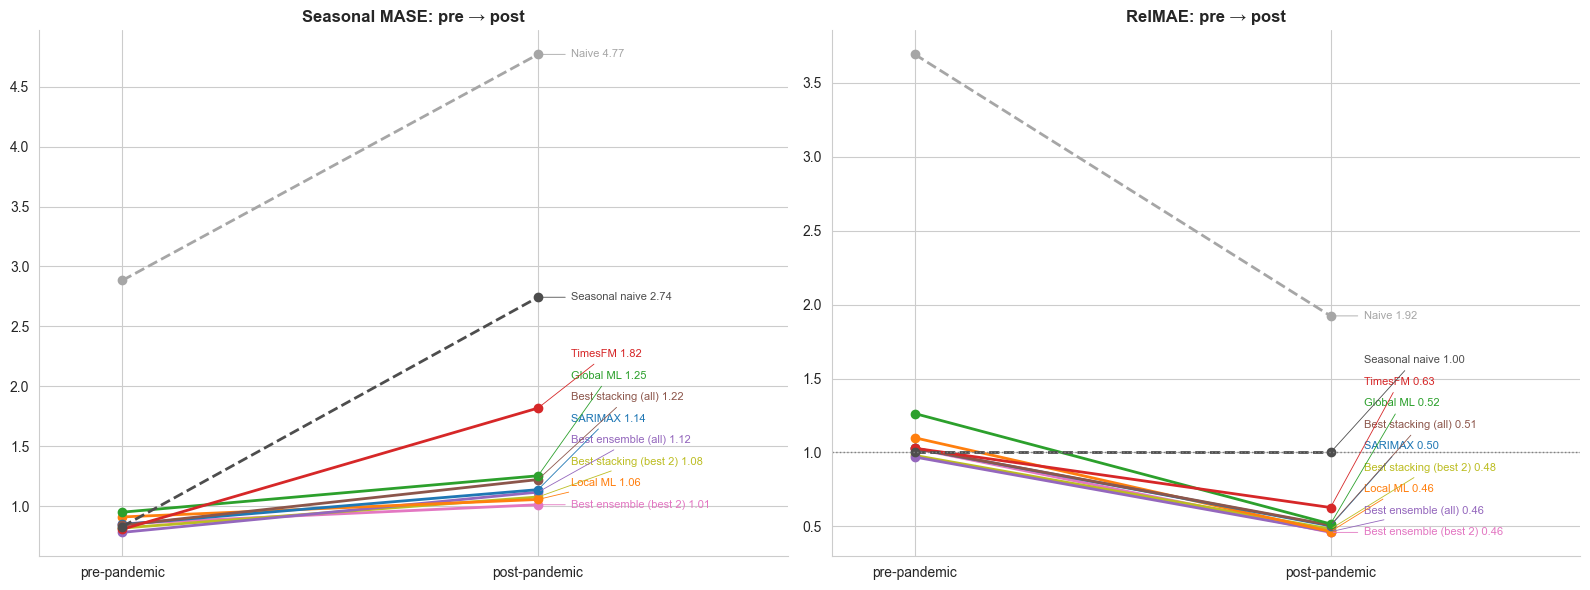

MASE  RelMAE        RMSE         MAE    MAPE     R2  Forecast Bias
Best ensemble (best 2) pre-pandemic   0.852   1.027   67348.650   44311.348   7.576  0.839         -2.639
                       post-pandemic  1.011   0.459   75887.755   52464.245   7.403  0.911          2.067
Best stacking (best 2) pre-pandemic   0.817   0.980   66503.529   42454.446   7.226  0.842         -2.024
                       post-pandemic  1.076   0.482   79171.148   55834.417   7.938  0.908          3.865
Best ensemble (all)    pre-pandemic   0.781   0.969   57028.596   40615.232   7.412  0.897         -0.818
                       post-pandemic  1.117   0.464   85141.333   57953.409   7.960  0.901          6.221
Local ML               pre-pandemic   0.909   1.099   71503.996   47281.175   7.958  0.817         -4.289
                       post-pandemic  1.055   0.465   74235.746   54754.520   8.145  0.913         -0.945
SARIMAX                pre-pandemic   0.847   1.028   66704.323   44030.419   7.612  0.851         -0.989
                       post-pandemic  1.137   0.504   86799.388   59012.679   8.404  0.891          5.079
Best stacking (all)    pre-pandemic   0.840   1.028   64108.548   43703.044   7.667  0.865          1.560
                       post-pandemic  1.221   0.508   89592.142   63390.296   8.748  0.890          5.703
Global ML              pre-pandemic   0.949   1.263   71177.463   49501.857   8.934  0.864          1.136
                       post-pandemic  1.253   0.517   94000.036   65026.894   9.077  0.880          7.404
TimesFM                pre-pandemic   0.806   1.029   62114.285   41994.874   7.487  0.884          0.871
                       post-pandemic  1.818   0.628  121479.562   94421.216  12.621  0.803         13.347
Seasonal naive         pre-pandemic   0.829   1.000   67070.677   43084.417   7.217  0.851         -0.562
                       post-pandemic  2.743   1.000  171823.300  142437.417  20.966  0.608         20.957
Naive                  pre-pandemic   2.883   3.694  228397.738  150188.542  22.029 -0.423         22.807
                       post-pandemic  4.771   1.924  360009.450  247636.625  29.828 -0.792         37.118

In [99]:
PERIODS = ['pre-pandemic', 'post-pandemic']
by_period = per_origin.groupby(['approach', 'period'])[METRICS].mean()


def spread_labels(values, min_gap):
    """Label positions at least `min_gap` apart, in the order of the values."""
    positions, last = {}, -np.inf
    for key, value in sorted(values.items(), key=lambda item: item[1]):
        last = max(value, last + min_gap)
        positions[key] = last
    return positions


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric in zip(axes, ['MASE', 'RelMAE']):
    ends = {a: by_period.loc[a, metric].reindex(PERIODS).iloc[1] for a in ORDER}
    values_range = by_period[metric].max() - by_period[metric].min()
    label_y = spread_labels(ends, min_gap=0.045 * values_range)
    for approach in ORDER:
        values = by_period.loc[approach, metric].reindex(PERIODS)
        is_baseline = approach in BASELINES
        ax.plot(
            [0, 1],
            values,
            marker='o',
            color=APPROACH_COLORS[approach],
            linestyle='--' if is_baseline else '-',
            linewidth=2,
        )
        ax.annotate(
            f'{approach} {values.iloc[1]:.2f}',
            xy=(1, values.iloc[1]),
            xytext=(1.08, label_y[approach]),
            va='center',
            fontsize=8,
            color=APPROACH_COLORS[approach],
            arrowprops={
                'arrowstyle': '-',
                'color': APPROACH_COLORS[approach],
                'lw': 0.6,
            },
        )
    ax.set_xticks([0, 1], PERIODS)
    ax.set_xlim(-0.2, 1.6)
    ax.set_title(
        f'{"Seasonal MASE" if metric == "MASE" else "RelMAE"}: pre → post',
        fontweight='bold',
    )
    if metric == 'RelMAE':
        ax.axhline(1, color='grey', linestyle=':', linewidth=1)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

by_period.reindex(pd.MultiIndex.from_product([ORDER, PERIODS])).round(3)

In [100]:
post_origins = [label for label in ORIGIN_LABELS if ORIGINS[label] >= COVID_START]
shock = post_origins[-1]
snaive_post = per_origin[
    (per_origin['approach'] == 'Seasonal naive')
    & per_origin['origin'].isin(post_origins)
].set_index('origin')['MASE']
best_pre = by_period.xs('pre-pandemic', level='period').loc[models, 'MASE'].idxmin()
best_post = by_period.xs('post-pandemic', level='period').loc[models, 'MASE'].idxmin()
best_post_rel = (
    by_period.xs('post-pandemic', level='period').loc[models, 'RelMAE'].idxmin()
)
display(
    Markdown(f"""
**Reading — Step 2.** Before the pandemic the best approach is **{best_pre}**;
after it, **{best_post}** by seasonal MASE and **{best_post_rel}** by RelMAE.
The approaches score worse after the pandemic, but most of that is the {shock}
window: even the seasonal naive goes from MASE {snaive_post.iloc[0]:.2f}
({post_origins[0]}) to {snaive_post.iloc[-1]:.2f} ({shock}), so the
post-pandemic mean is dominated by one shock window. The RelMAE panel removes
that common difficulty: an approach whose RelMAE stays below 1 in both periods
beats "same month last year" in both regimes, whatever the level of its MASE.
""")
)


**Reading — Step 2.** Before the pandemic the best approach is **Best ensemble (all)**;
after it, **Best ensemble (best 2)** by seasonal MASE and **Best ensemble (best 2)** by RelMAE.
The approaches score worse after the pandemic, but most of that is the 2024-08
window: even the seasonal naive goes from MASE 1.46
(2023-08) to 4.02 (2024-08), so the
post-pandemic mean is dominated by one shock window. The RelMAE panel removes
that common difficulty: an approach whose RelMAE stays below 1 in both periods
beats "same month last year" in both regimes, whatever the level of its MASE.


## Step 3 — Flat vs Rapid-Growth Years

Each validation window (the 12 forecast months of an origin) is labelled as a whole by how much
the total arrivals grew from the year before:

`g = (sum of the actuals over the 12 validation months) / (sum of the actuals over the 12 months before them) − 1`

The 12 months before a window are the last 12 months of the history at its origin, so `g`
compares two full years and the seasonality cancels out.

| Regime | Rule |
|---|---|
| **flat** | `|g| ≤ FLAT_GROWTH` (5%) |
| **rapid growth** | `g ≥ RAPID_GROWTH` (30%) |
| **normal growth** | everything in between: `FLAT_GROWTH < g < RAPID_GROWTH` (a decline beyond −5% would also land here) |

- The labels use the actual values only to **classify the windows for evaluation**; they are
  never a model input. All the values come from the train and validation data.
- When the previous year overlaps the pandemic or the recovery (April 2020 – June 2022), the
  growth is partly a rebound from a depressed base rather than organic growth; such windows are
  flagged (hatched in the chart).
- The metrics of a regime are the **mean of the per-origin metrics** of its windows, as in
  Step 2. With four windows, a regime holds one or two of them, so Step 3 illustrates rather than
  proves.

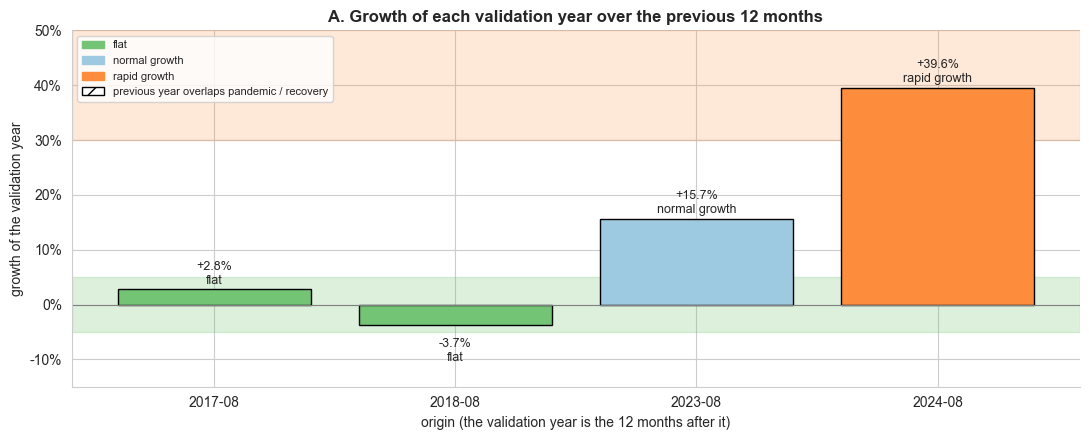

,period,previous 12 months,validation year,growth g,base affected,regime
origin,,,,,,
2017-08,pre-pandemic,6474132.0,6655969.0,+2.8%,False,flat
2018-08,pre-pandemic,6655969.0,6408872.0,-3.7%,False,flat
2023-08,post-pandemic,5480640.0,6340127.0,+15.7%,False,normal growth
2024-08,post-pandemic,6340127.0,8849640.0,+39.6%,False,rapid growth


In [101]:
windows = []
for label, origin in ORIGINS.items():
    previous = full_series.loc[origin - pd.offsets.MonthEnd(11) : origin]
    year = full_series.loc[
        origin + pd.offsets.MonthEnd(1) : origin + pd.offsets.MonthEnd(12)
    ]
    assert len(previous) == len(year) == SEASONAL_PERIOD
    windows.append({
        'origin': label,
        'period': 'pre-pandemic' if origin < COVID_START else 'post-pandemic',
        'previous 12 months': previous.sum(),
        'validation year': year.sum(),
        'growth g': year.sum() / previous.sum() - 1,
        'base affected': bool(
            previous.index.min() <= BASE_AFFECTED[1]
            and previous.index.max() >= BASE_AFFECTED[0]
        ),
    })
windows = pd.DataFrame(windows).set_index('origin')
windows['regime'] = np.select(
    [windows['growth g'].abs() <= FLAT_GROWTH, windows['growth g'] >= RAPID_GROWTH],
    ['flat', 'rapid growth'],
    default='normal growth',
)

REGIME_COLORS = {
    'flat': '#74c476',
    'normal growth': '#9ecae1',
    'rapid growth': '#fd8d3c',
}
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axhspan(-FLAT_GROWTH, FLAT_GROWTH, color=REGIME_COLORS['flat'], alpha=0.25)
ax.axhspan(
    RAPID_GROWTH,
    max(0.5, windows['growth g'].max() + 0.1),
    color=REGIME_COLORS['rapid growth'],
    alpha=0.2,
)
bars = ax.bar(
    windows.index,
    windows['growth g'],
    color=windows['regime'].map(REGIME_COLORS),
    edgecolor='black',
)
for bar, (_, row) in zip(bars, windows.iterrows()):
    bar.set_hatch('//' if row['base affected'] else '')
    ax.annotate(
        f'{row["growth g"]:+.1%}\n{row["regime"]}',
        (bar.get_x() + bar.get_width() / 2, row['growth g']),
        xytext=(0, 4 if row['growth g'] >= 0 else -26),
        textcoords='offset points',
        ha='center',
        fontsize=9,
    )
ax.axhline(0, color='grey', linewidth=0.8)
# room for the labels under negative bars and above the highest one
ax.set_ylim(
    min(-FLAT_GROWTH, windows['growth g'].min()) - 0.1,
    max(0.5, windows['growth g'].max() + 0.1),
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('origin (the validation year is the 12 months after it)')
ax.set_ylabel('growth of the validation year')
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=regime)
    for regime, color in REGIME_COLORS.items()
] + [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor='white',
        edgecolor='black',
        hatch='//',
        label='previous year overlaps pandemic / recovery',
    )
]
ax.legend(handles=handles, fontsize=8, loc='upper left')
ax.set_title(
    'A. Growth of each validation year over the previous 12 months',
    fontweight='bold',
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

windows.assign(**{'growth g': windows['growth g'].map('{:+.1%}'.format)}).round(0)

period,pre-pandemic,post-pandemic,windows,base affected
regime,,,,
flat,2,0,2,0
normal growth,0,1,1,0
rapid growth,0,1,1,0


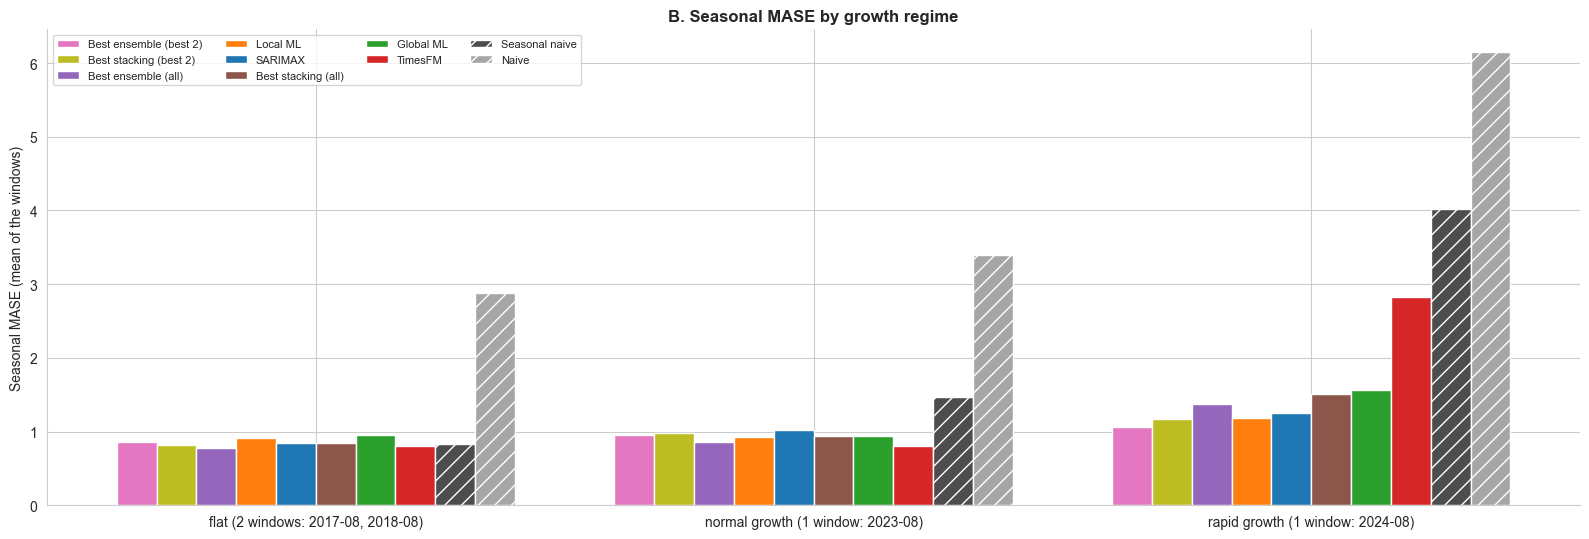

MASE  RelMAE        RMSE         MAE    MAPE     R2  Forecast Bias
Best ensemble (best 2) flat           0.852   1.027   67348.650   44311.348   7.576  0.839         -2.639
                       normal growth  0.957   0.654   68310.076   49538.705   8.762  0.885          0.844
                       rapid growth   1.066   0.265   83465.433   55389.785   6.045  0.937          3.291
Best stacking (best 2) flat           0.817   0.980   66503.529   42454.446   7.226  0.842         -2.024
                       normal growth  0.987   0.675   65959.770   51107.616   9.448  0.893          2.618
                       rapid growth   1.165   0.290   92382.527   60561.217   6.428  0.922          5.113
Best ensemble (all)    flat           0.781   0.969   57028.596   40615.232   7.412  0.897         -0.818
                       normal growth  0.856   0.585   58392.774   44337.916   8.142  0.916          3.448
                       rapid growth   1.377   0.342  111889.892   71568.901   7.778  0.886          8.995
Local ML               flat           0.909   1.099   71503.996   47281.175   7.958  0.817         -4.289
                       normal growth  0.932   0.637   68355.526   48249.564   8.501  0.885         -0.541
                       rapid growth   1.179   0.293   80115.966   61259.475   7.788  0.942         -1.349
SARIMAX                flat           0.847   1.028   66704.323   44030.419   7.612  0.851         -0.989
                       normal growth  1.017   0.695   69905.692   52666.774   9.505  0.880          2.228
                       rapid growth   1.258   0.313  103693.084   65358.584   7.302  0.902          7.931
Best stacking (all)    flat           0.840   1.028   64108.548   43703.044   7.667  0.865          1.560
                       normal growth  0.939   0.642   63411.371   48648.219   8.947  0.901          2.553
                       rapid growth   1.503   0.374  115772.913   78132.373   8.549  0.878          8.854
Global ML              flat           0.949   1.263   71177.463   49501.857   8.934  0.864          1.136
                       normal growth  0.943   0.645   62898.479   48839.716   9.104  0.903          5.345
                       rapid growth   1.563   0.388  125101.593   81214.072   9.051  0.858          9.463
TimesFM                flat           0.806   1.029   62114.285   41994.874   7.487  0.884          0.871
                       normal growth  0.808   0.552   58742.202   41826.854   7.426  0.915          6.758
                       rapid growth   2.829   0.703  184216.923  147015.578  17.815  0.691         19.935
Seasonal naive         flat           0.829   1.000   67070.677   43084.417   7.217  0.851         -0.562
                       normal growth  1.463   1.000   88293.484   75748.750  15.454  0.809         13.556
                       rapid growth   4.024   1.000  255353.116  209126.083  26.478  0.407         28.357
Naive                  flat           2.883   3.694  228397.738  150188.542  22.029 -0.423         22.807
                       normal growth  3.393   2.320  259578.406  175743.250  25.689 -0.655         30.908
                       rapid growth   6.148   1.528  460440.495  319530.000  33.968 -0.929         43.328

In [102]:
REGIMES = ['flat', 'normal growth', 'rapid growth']
per_origin['regime'] = per_origin['origin'].map(windows['regime'])

crosstab = pd.crosstab(windows['regime'], windows['period']).reindex(
    index=REGIMES, columns=PERIODS, fill_value=0
)
crosstab['windows'] = crosstab.sum(axis=1)
crosstab['base affected'] = (
    windows
    .groupby('regime')['base affected']
    .sum()
    .reindex(crosstab.index, fill_value=0)
)
display(crosstab)

by_regime = (
    per_origin[per_origin['regime'].isin(REGIMES)]
    .groupby(['approach', 'regime'])[METRICS]
    .mean()
)

fig, ax = plt.subplots(figsize=(16, 5.5))
width = 0.8 / len(ORDER)
for i, approach in enumerate(ORDER):
    values = by_regime['MASE'].reindex(
        pd.MultiIndex.from_product([[approach], REGIMES])
    )
    ax.bar(
        np.arange(len(REGIMES)) + i * width,
        values.to_numpy(),
        width,
        color=APPROACH_COLORS[approach],
        label=approach,
        hatch='//' if approach in BASELINES else None,
        edgecolor='white',
    )
ax.set_xticks(
    np.arange(len(REGIMES)) + width * (len(ORDER) - 1) / 2,
    [
        f'{regime} ({crosstab.loc[regime, "windows"]} '
        f'window{"" if crosstab.loc[regime, "windows"] == 1 else "s"}: '
        f'{", ".join(windows.index[windows["regime"] == regime]) or "none"})'
        for regime in REGIMES
    ],
)
ax.set_ylabel('Seasonal MASE (mean of the windows)')
ax.set_title('B. Seasonal MASE by growth regime', fontweight='bold')
ax.legend(fontsize=8, ncol=4)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

by_regime.reindex(pd.MultiIndex.from_product([ORDER, REGIMES])).round(3)

In [103]:
flat_periods = set(windows.loc[windows['regime'] == 'flat', 'period'])
rapid_periods = set(windows.loc[windows['regime'] == 'rapid growth', 'period'])
confounded = flat_periods <= {'pre-pandemic'} and rapid_periods <= {'post-pandemic'}


def best_in(regime):
    if crosstab.loc[regime, 'windows'] == 0:
        return 'n/a (no window)'
    return by_regime.xs(regime, level='regime').loc[models, 'MASE'].idxmin()


growth_list = ', '.join(
    f'{label} {row["growth g"]:+.1%} ({row["regime"]})'
    for label, row in windows.iterrows()
)
overlap_note = (
    '**Every flat year is pre-pandemic and every rapid-growth year is post-pandemic**, '
    'so Step 3 repeats the split of Step 2; it is not independent evidence.'
    if confounded
    else 'The regimes do not simply copy the periods (see the table), so Step 3 adds a '
    'view that Step 2 does not have.'
)
affected = windows.index[windows['base affected']].tolist()
affected_note = (
    f'The previous year of {", ".join(affected)} overlaps the pandemic or recovery, so '
    'part of its growth is a rebound.'
    if affected
    else 'No previous year overlaps the pandemic or recovery.'
)
display(
    Markdown(f"""
**Reading — Step 3.** Growth of each validation year: {growth_list}. {overlap_note}
{affected_note} The best approach on the flat years is
**{best_in('flat')}**, on the normal-growth years **{best_in('normal growth')}**
and on the rapid-growth years **{best_in('rapid growth')}**. Each regime holds
one or two windows, so these
differences illustrate how the approaches react to growth rather than establish
it.
""")
)


**Reading — Step 3.** Growth of each validation year: 2017-08 +2.8% (flat), 2018-08 -3.7% (flat), 2023-08 +15.7% (normal growth), 2024-08 +39.6% (rapid growth). **Every flat year is pre-pandemic and every rapid-growth year is post-pandemic**, so Step 3 repeats the split of Step 2; it is not independent evidence.
No previous year overlaps the pandemic or recovery. The best approach on the flat years is
**Best ensemble (all)**, on the normal-growth years **TimesFM**
and on the rapid-growth years **Best ensemble (best 2)**. Each regime holds
one or two windows, so these
differences illustrate how the approaches react to growth rather than establish
it.


## Final Summary

Seasonal MASE (left) and RMSE (right) of every approach in every view: overall (mean over the
four origins), pre- and post-pandemic (mean of their two origins), and flat, normal-growth and
rapid-growth years (mean of the origins in each regime). Lower is better; the colour is the
rank within each column. The RMSE is in arrivals, so it weighs the large misses of the
high-level windows (such as 2024-08) much more than the MASE, which is scaled per origin.

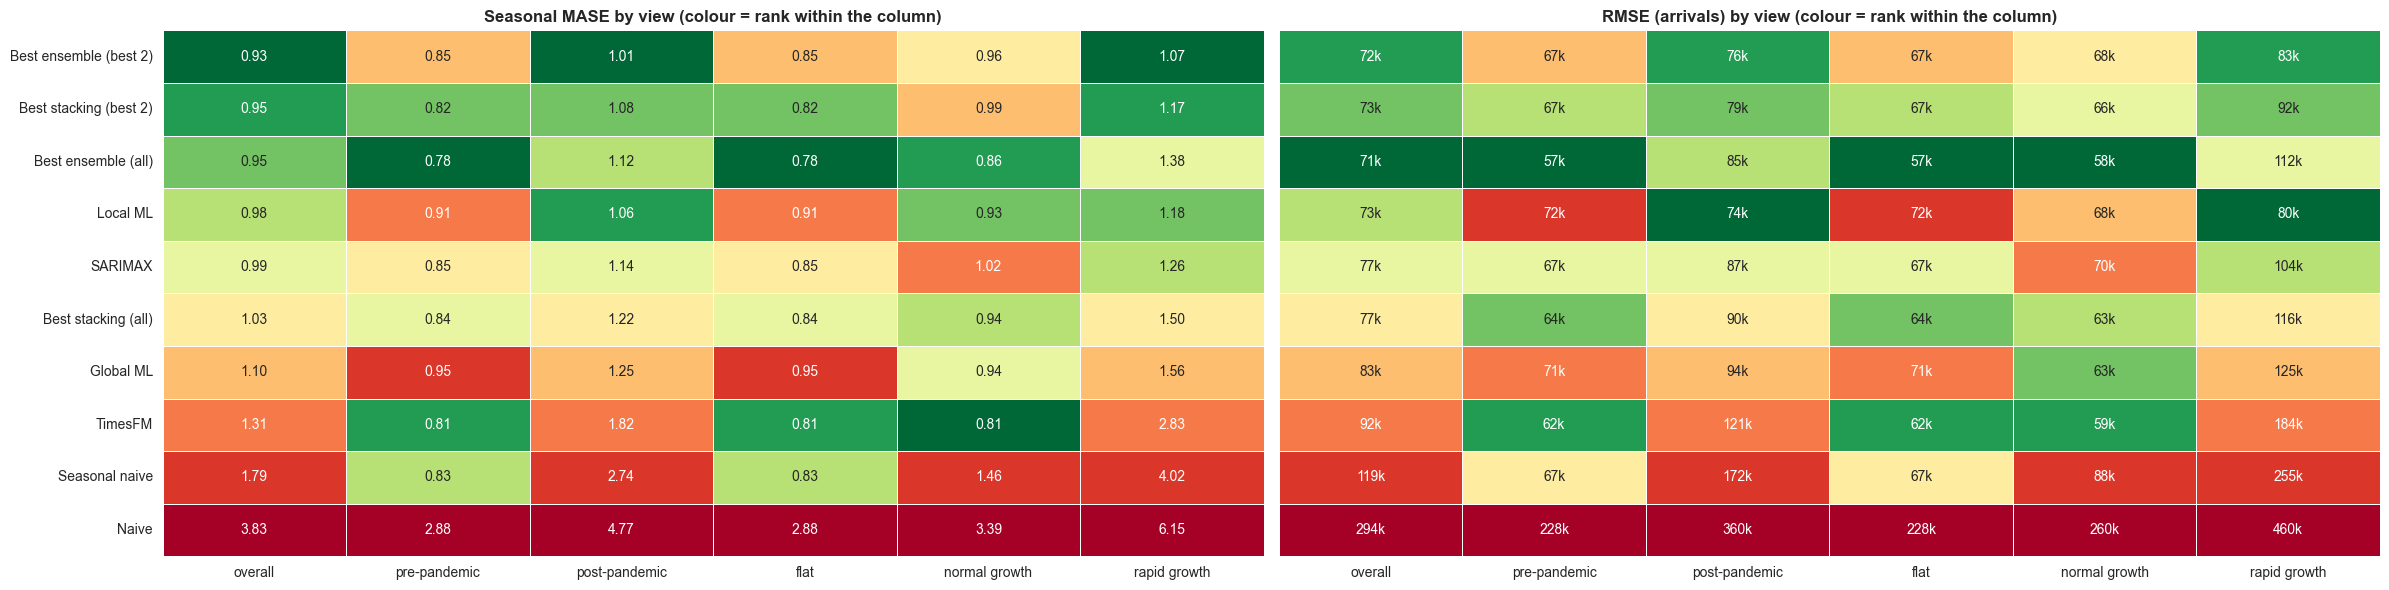

**Summary.** Best approach per view: overall: **Best ensemble (best 2)**; pre-pandemic: **Best ensemble (all)**; post-pandemic: **Best ensemble (best 2)**; flat: **Best ensemble (all)**; normal growth: **TimesFM**; rapid growth: **Best ensemble (best 2)** (by seasonal MASE); overall: **Best ensemble (all)**; pre-pandemic: **Best ensemble (all)**; post-pandemic: **Local ML**; flat: **Best ensemble (all)**; normal growth: **Best ensemble (all)**; rapid growth: **Local ML** (by RMSE). These are validation results only; the approaches were selected on these same four origins, so they are optimistic, and no conclusion about the test year is drawn here.

In [104]:
def view_table(metric):
    """`metric` of every approach in every view: overall, periods and growth regimes."""
    return pd.DataFrame({
        'overall': overall[metric],
        'pre-pandemic': by_period.xs('pre-pandemic', level='period')[metric],
        'post-pandemic': by_period.xs('post-pandemic', level='period')[metric],
        **{
            regime: by_regime.xs(regime, level='regime')[metric]
            if regime in by_regime.index.get_level_values('regime')
            else np.nan
            for regime in REGIMES
        },
    }).reindex(ORDER)


summary = view_table('MASE')
summary_rmse = view_table('RMSE')

fig, axes = plt.subplots(1, 2, figsize=(24, 6), sharey=True)
for ax, table, title, label in [
    (axes[0], summary, 'Seasonal MASE', lambda v: f'{v:.2f}'),
    (axes[1], summary_rmse, 'RMSE (arrivals)', lambda v: f'{v / 1e3:,.0f}k'),
]:
    sns.heatmap(
        table.rank(axis=0),
        annot=table.map(lambda v, label=label: '' if pd.isna(v) else label(v)),
        fmt='',
        cmap='RdYlGn_r',
        cbar=False,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title(
        f'{title} by view (colour = rank within the column)', fontweight='bold'
    )
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

wins = summary.loc[models].dropna(axis=1, how='all').idxmin()  # skip empty regimes
wins_rmse = summary_rmse.loc[models].dropna(axis=1, how='all').idxmin()
display(
    Markdown(
        '**Summary.** Best approach per view: '
        + '; '.join(f'{view}: **{approach}**' for view, approach in wins.items())
        + ' (by seasonal MASE); '
        + '; '.join(f'{view}: **{approach}**' for view, approach in wins_rmse.items())
        + ' (by RMSE)'
        + '. These are validation results only; the approaches were selected on these '
        'same four origins, so they are optimistic, and no conclusion about the test '
        'year is drawn here.'
    )
)